In [1]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
from pysal.viz import mapclassify
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx

In [2]:
df = pd.read_csv("transformed_output.csv")
df["start_time"] = pd.to_datetime(df["start_time"])
df = df[df["area_name"] != "NOT_ANNOTATED"]  # drop untagged rows

area_counts = df.groupby("area_name").size().reset_index(name="visit_count")
print(area_counts.sort_values("visit_count", ascending=False))

          area_name  visit_count
15      Kobenhavn K        38025
21      Kobenhavn V        35873
19      Kobenhavn S        35530
18      Kobenhavn O        32788
6   Frederiksberg C        31628
13      Kgs. Lyngby        23641
16      Kobenhavn N        23185
27            Valby        22416
9          Hellerup        21099
17     Kobenhavn NV        20964
7          Gentofte        19085
4     Charlottelund        18846
12          Kastrup        16609
25           Soborg        13877
20     Kobenhavn SV        11250
3          Bronshoj         9610
23          Rodovre         9490
28          Vanlose         9481
5        Dyssegoord         5049
14      Klampenborg         4769
11         Hvidovre         4735
10           Herlev         4494
22         Nordhavn         4207
1         Bagsvaerd         3701
8          Glostrup         3327
24        Skovlunde         2191
26         Taastrup         1822
29            Virum         1788
0       Albertslund           67
2         

In [ ]:
muni = gpd.read_file("municipalities_dk.gpkg")
#muni = gpd.read_file("denmark.gpkg")

area_to_muni = {
    "Kobenhavn K":    "København",
    "Kobenhavn V":    "København",
    "Kobenhavn N":    "København",
    "Kobenhavn O":    "København",
    "Kobenhavn S":    "København",
    "Kobenhavn NV":   "København",
    "Kobenhavn SV":   "København",
    "Nordhavn":       "København",
    "Valby":          "København",
    "Vanlose":        "København",
    "Bronshoj":       "København",
    "Kastrup":        "København",
    "Frederiksberg C":"Frederiksberg",
    "Gentofte":       "Gentofte",
    "Hellerup":       "Gentofte",
    "Charlottelund":  "Gentofte",
    "Klampenborg":    "Gentofte",
    "Dyssegoord":     "Gentofte",
    "Kgs. Lyngby":    "Lyngby-Taarbæk",
    "Virum":          "Lyngby-Taarbæk",
    "Soborg":         "Gladsaxe",
    "Bagsvaerd":      "Gladsaxe",
    "Herlev":         "Herlev",
    "Hvidovre":       "Hvidovre",
    "Rodovre":        "Rødovre",
    "Glostrup":       "Glostrup",
    "Albertslund":    "Albertslund",
    "Skovlunde":      "Ballerup",
    "Ballerup":       "Ballerup",
    "Taastrup":       "Høje-Taastrup",
}

area_counts['municipality'] = area_counts['area_name'].map(area_to_muni)
muni_counts = area_counts.groupby('municipality')['visit_count'].sum().reset_index()
print(muni_counts.sort_values('visit_count', ascending=False))

muni_map = muni.set_index('navn').join(muni_counts.set_index('municipality'), how='inner')
print(f"\nMatched {len(muni_map)} municipalities")

      municipality  visit_count
9        København       259938
3         Gentofte        68848
2    Frederiksberg        31628
10  Lyngby-Taarbæk        25429
4         Gladsaxe        17578
11         Rødovre         9490
7         Hvidovre         4735
6           Herlev         4494
5         Glostrup         3327
1         Ballerup         2193
8    Høje-Taastrup         1822
0      Albertslund           67

Matched 12 municipalities


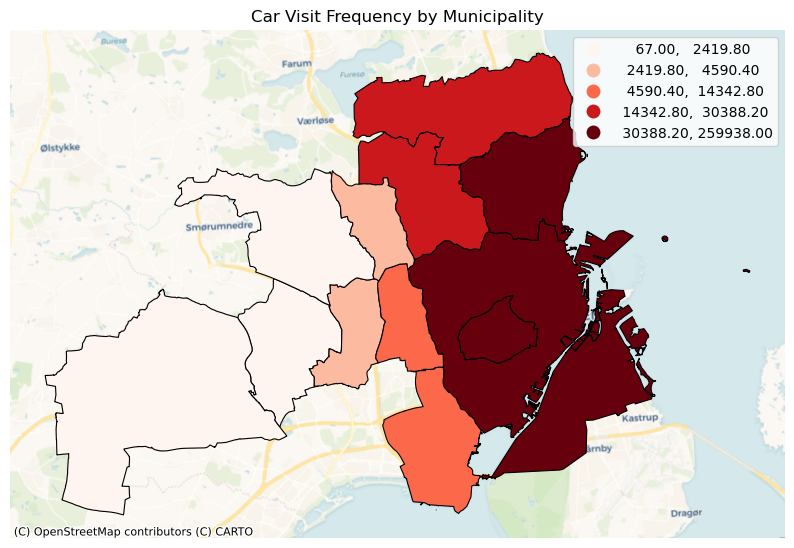

In [4]:

fig, ax = plt.subplots(1, figsize=(10, 10))

muni_map.plot(ax=ax,
    column='visit_count',
    scheme='quantiles',
    k=5,
    cmap='Reds',
    legend=True,
    edgecolor='black',
    linewidth=0.8
)

ax.set_axis_off()
ax.set_title('Car Visit Frequency by Municipality')

cx.add_basemap(
    ax,
    crs=muni_map.crs,
    source=cx.providers.CartoDB.Voyager
)

plt.show()